In [169]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [170]:
#Correzione distanza oggetto
ogg = 74.0
#Lunghezza per Bessel con correzione
L = 561 + ogg

# 1. Punti Coniugati


In [171]:
metodo = "Coniugati"

### 1.1 Lettura

In [172]:
def nome (stringa, cartella):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/dati_','').replace('.csv','')
    return stringa_nuova

In [173]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data1 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data1[nome(input_file, metodo)] = {
        "immagine": letti["immagine"],
        "lente": letti["lente"],
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

In [174]:
distanze = {}
focali1 = {}

for colore,dati in data1.items():
    if colore=="rosso":
        p = np.array(dati["lente"]) + ogg - 7
    else:
        p = np.array(dati["lente"]) + ogg
    q = np.array(dati["immagine"]) - np.array(dati["lente"])

    anal = f.elaborato(1/q, 1/p, 0.5/(p*p), "test.txt", 0, vsx = 0.5/(q*q), ritorno = True)

    print(f"b = {anal[1]}")
        
    print(f"p-value = {anal[5]}")

    distanze[colore] = {
        "p" : p,
        "q" : q,
    }

    focali1[colore] = {
        "f" : 1/anal[0],
        "sf" : anal[2]/anal[0]**2
    }


Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -0.9843441630084413
p-value = 5.556578070447376e-65

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -1.0200140418737593
p-value = 5.3301163127085456e-58

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -0.9957105738819009
p-value = 0.8655228719844565


### 1.3 Grafici

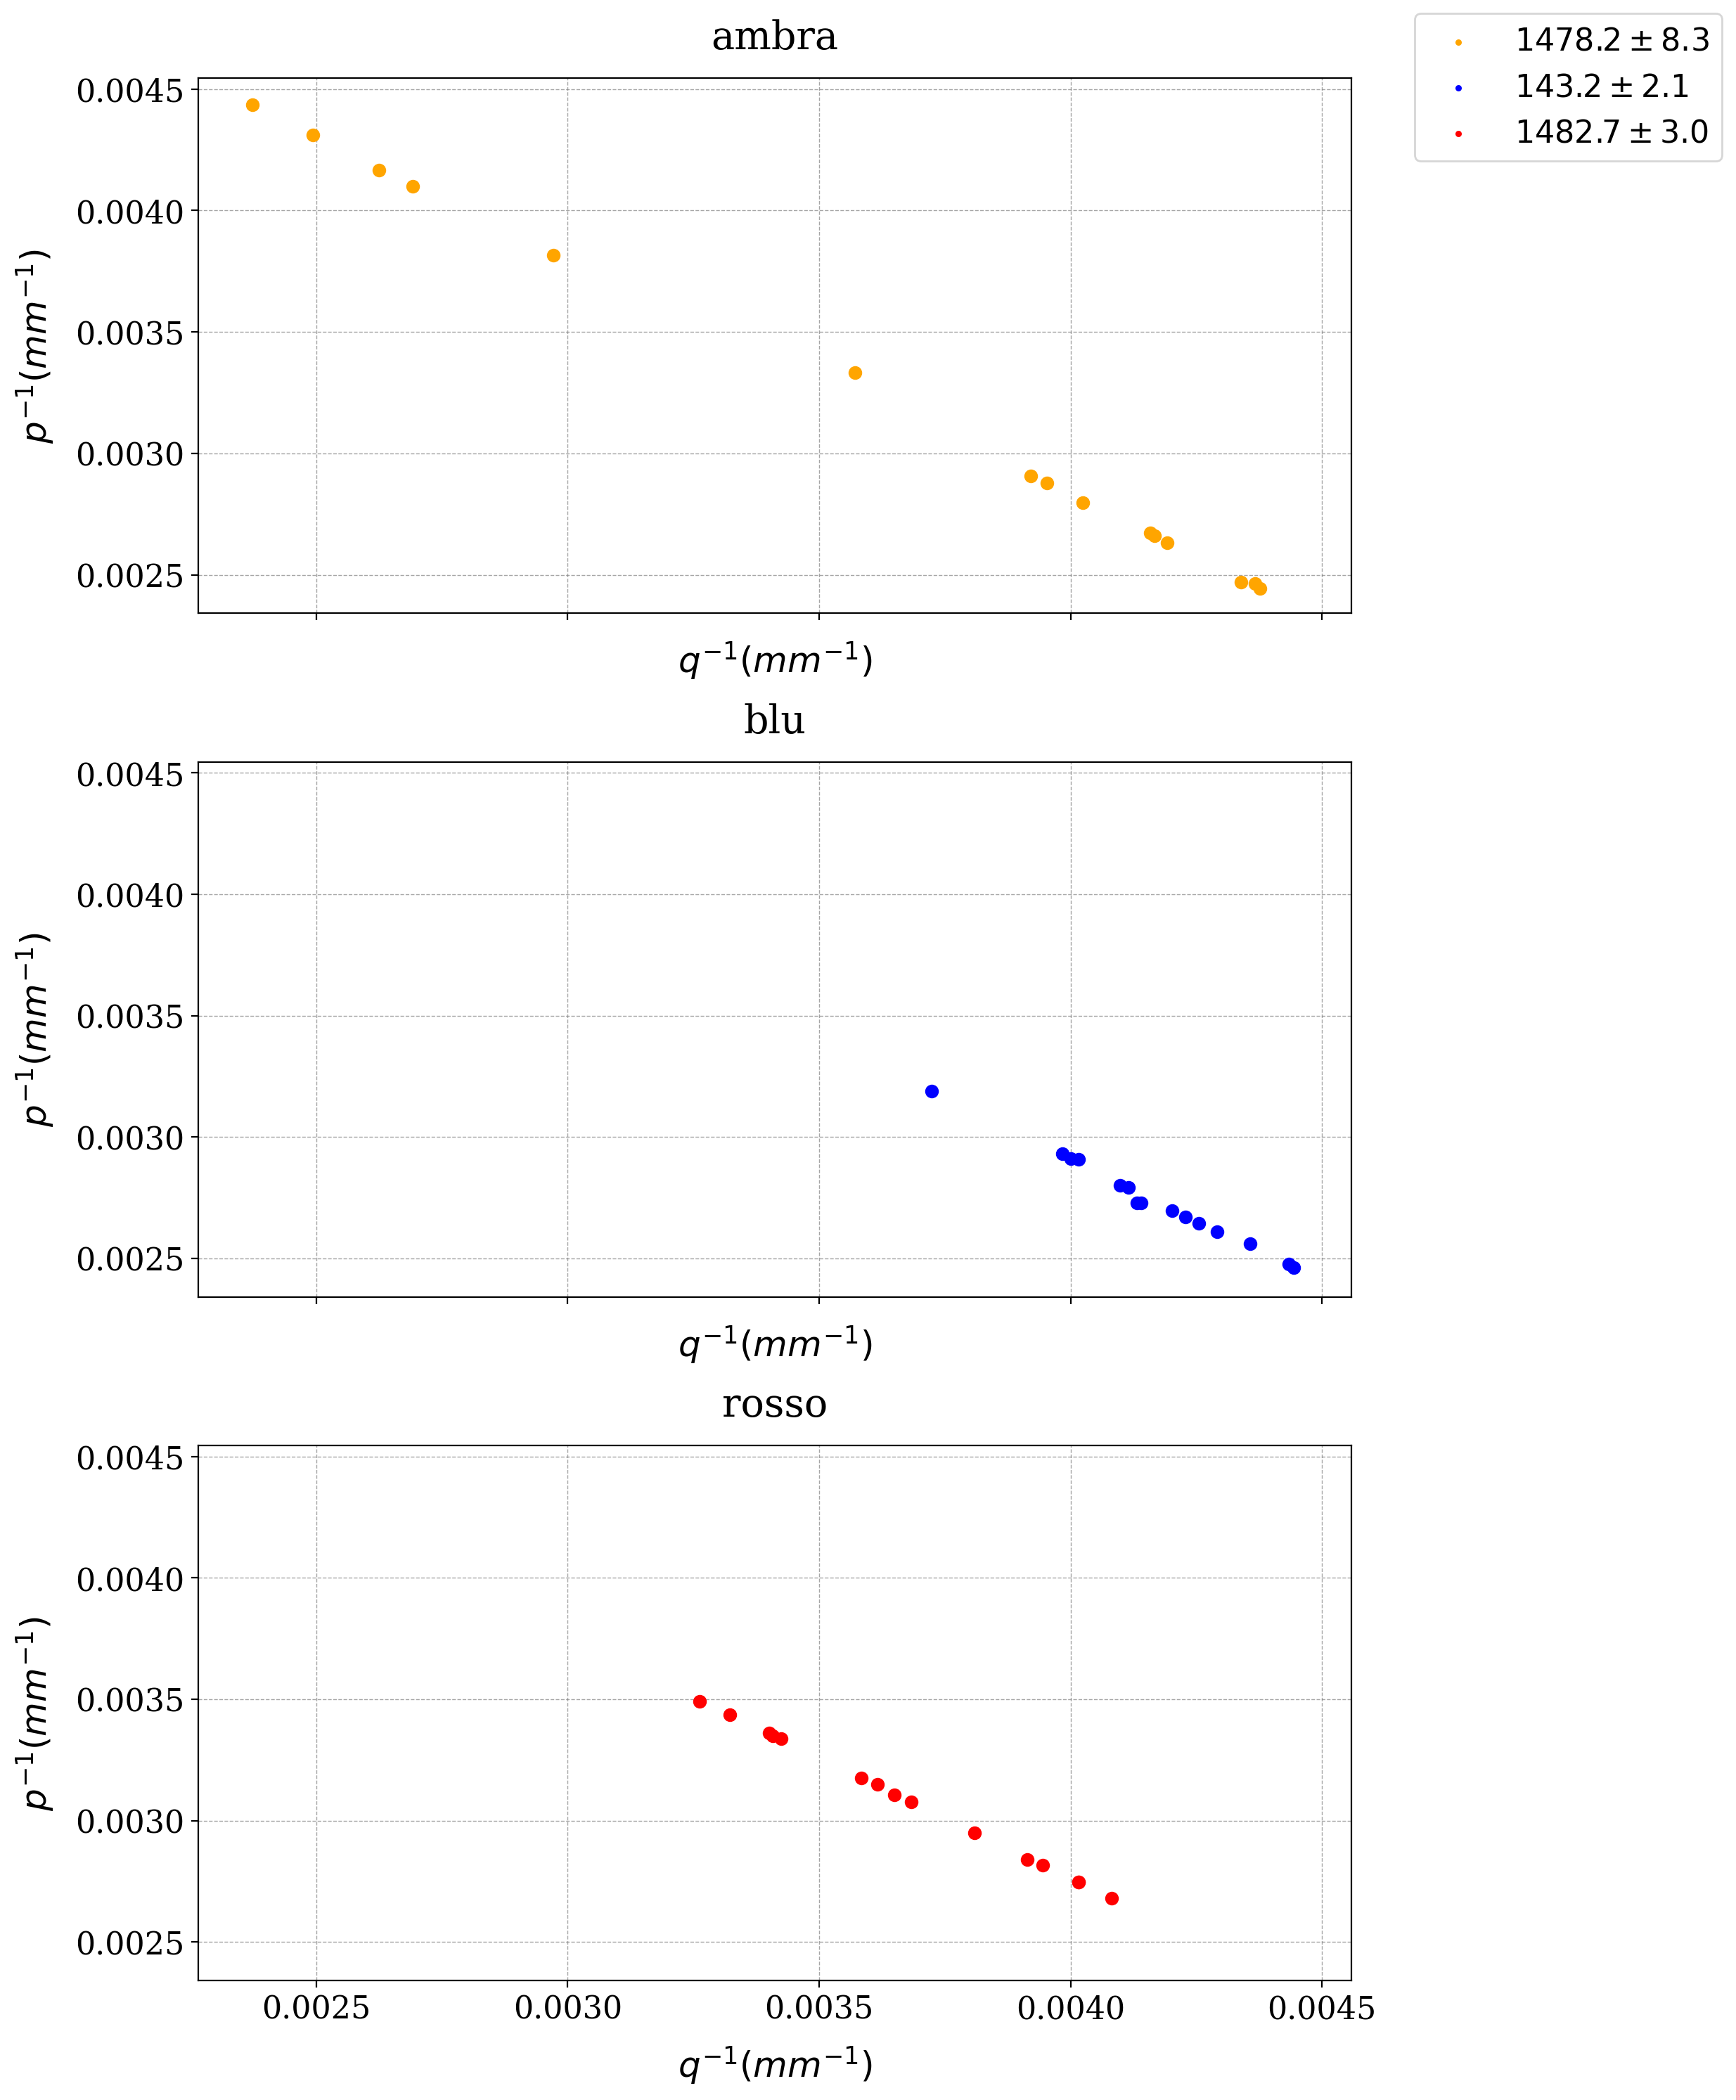

In [175]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

ax = axes

titolo = "Test"

for i, (input_file, distanza, focali) in enumerate(zip(input_files, distanze.values(), focali1.values())):

    ax = axes[i]

    titolo = nome(input_file, metodo)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(1/q, 1/p, xerr = 0.5/(q*q) , yerr = 0.5/(p*p), color=colore, fmt = 'o')
    #meme.scrivi(ax,"CHE SCHIFO", densita=1000)
    #gf.numera_punti(ax,q,p)

    stringa_f = gf.formatta_errore(focali["f"],focali["sf"])

    gf.parametri_grafico(ax, titolo, "$q^{-1}(mm^{-1})$", "$p^{-1}(mm^{-1})$")
    gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici.pdf")

# 2. Bessel

In [176]:
metodo = "Bessel"

### 2.1 Lettura

In [177]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data2 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data2[nome(input_file, metodo)] = {
        "pl+": letti["pl+"],
        "pl-": letti["pl-"],
    }

In [178]:
gf.display_dizionario(data1)

In [179]:
gf.display_dizionario(data2)

### 2.2 Analisi

In [180]:
focali2 = {}

lunghezza = L

for colore,dati in data2.items():

    if colore=="rosso" : L = lunghezza - 7

    pl_piu = np.mean(np.array(dati["pl+"]))
    pl_meno = np.mean(np.array(dati["pl-"]))
    s_pl_piu = f.s_media(dati["pl+"])
    s_pl_meno = f.s_media(dati["pl-"])
    ritorno = f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)", ["L","pl_piu","pl_meno"],
                     valori = [L, pl_piu, pl_meno],
                     incertezze = [0.5/np.sqrt(12), s_pl_piu, s_pl_meno],
                     ritorno = True)
    focali2[colore] = {
        "f" : (L**2 - (pl_piu - pl_meno)**2) / (4 * L),
        "sf" : ritorno[0],
        }
    L = lunghezza

In [181]:
gf.display_dizionario(focali1)

In [182]:
gf.display_dizionario(focali2)

# 3. Aberrazione

In [183]:
metodo = "Aberrazione"

### 3.1 Lettura

In [185]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data3 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data3[nome(input_file, metodo)] = {
        "parassiale": letti["parassiale"],
        "marginale": letti["marginale"],
    }

In [187]:
gf.display_dizionario(data3)

### 3.2 Analisi

In [190]:
aberrazione_sferica = {}

for colore,dati in data3.items():

    f_marginale = np.mean(np.array(dati["marginale"]))
    f_parassiale = np.mean(np.array(dati["parassiale"]))
    s_f_marginale = f.s_media(dati["marginale"])
    s_f_parassiale = f.s_media(dati["parassiale"])
    ritorno = f.propaga_incertezza("f_parassiale - f_marginale", ["f_parassiale", "f_marginale"],
                     valori = [f_parassiale, f_marginale],
                     incertezze = [s_f_parassiale, s_f_parassiale],
                     ritorno = True)
    aberrazione_sferica[colore] = {
        "aberrazione_sferica" : f_parassiale - f_marginale,
        "s_aberrazione_sferica" : ritorno[0],
        }

In [191]:
gf.display_dizionario(aberrazione_sferica)